In [1]:
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from safetensors.torch import load_file
from modeling.bagel import (
    BagelConfig, Bagel, Qwen2Config, Qwen2ForCausalLM, SiglipVisionConfig, SiglipVisionModel
)
from transformers import AutoConfig
import numpy as np
from matplotlib import cm  # 导入颜色映射模块


/share/liujun/apps/anaconda3/envs/lxh-bagel/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import glob

load_dir = "attn_probs_dump"
gen_attn_file = glob.glob(f"./{load_dir}/gen_attn_probs_layer_*_ts_*_batch_0.pt")
und_attn_file = glob.glob(f"./{load_dir}/und_attn_probs_layer_*_ts_*_batch_0.pt")
print(gen_attn_file)
print(und_attn_file)


['./attn_probs_dump/gen_attn_probs_layer_16_ts_24_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_19_ts_34_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_20_ts_42_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_6_ts_11_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_22_ts_0_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_13_ts_34_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_9_ts_17_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_10_ts_22_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_18_ts_-1_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_3_ts_3_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_0_ts_48_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_25_ts_2_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_8_ts_17_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_12_ts_46_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_6_ts_39_batch_0.pt', './attn_probs_dump/gen_attn_probs_layer_7_ts_40_batch_0.pt', './attn_probs_dum

In [3]:
def attention_plot(attention, x_texts, y_texts=None, figsize=(15, 10), annot=False, figure_path='./figures',
                   figure_name='attention_weight.png',
                   vmin=None, vmax=None, symmetric=False, percentile=None, square=True,
                   norm_type="linear", gamma=0.5):
    plt.clf()
    sns.set_theme(font_scale=1.25)

    arr = attention.detach().cpu().numpy() if hasattr(attention, "detach") else np.asarray(attention)
    if percentile is not None:
      lowp, highp = percentile
      vmin_p = np.percentile(arr, lowp)
      vmax_p = np.percentile(arr, highp)
      vmin = vmin_p if vmin is None else vmin
      vmax = vmax_p if vmax is None else vmax
    # fallback bounds
    if vmin is None: vmin = float(np.nanmin(arr))
    if vmax is None: vmax = float(np.nanmax(arr))

    # build norm
    from matplotlib.colors import Normalize, PowerNorm, LogNorm
    if norm_type == "power":
        norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    elif norm_type == "log":
        # ensure positive domain for LogNorm
        pos = arr[arr > 0]
        if pos.size == 0:
            # nothing positive -> fallback to linear
            norm = Normalize(vmin=vmin, vmax=vmax)
        else:
            vmin_pos = max(float(np.min(pos)), 1e-12)
            vmax_pos = vmax if vmax > vmin_pos else float(np.max(pos))
            norm = LogNorm(vmin=vmin_pos, vmax=vmax_pos)
    elif norm_type == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = None
    
    # Dynamically adjust figsize based on the shape of the attention matrix
    rows, cols = arr.shape
    aspect_ratio = cols / rows
    base_size = 10  # Base size for the shorter dimension
    if aspect_ratio > 1:  # Wider than tall
        figsize = (base_size * aspect_ratio, base_size)
    else:  # Taller than wide
        figsize = (base_size, base_size / aspect_ratio)
    fig, ax = plt.subplots(figsize=figsize)

    hm = sns.heatmap(arr,
                     cbar=True,
                     cmap="rocket_r",
                     norm=norm,
                     annot=annot,
                     square=square,
                     fmt='.2f',
                     annot_kws={'size': 10},
                    #  yticklabels=y_texts,
                    #  xticklabels=x_texts
                     yticklabels=False,
                     xticklabels=False,
                     vmin=vmin, vmax=vmax
                     )
    plt.show()

def plot_attn_map_distribution(attn_map, title="distribution", vmin=None, vmax=None):
    attn_map_np = attn_map.detach().cpu().numpy() if hasattr(attn_map, "detach") else np.asarray(attn_map)
    plt.figure(figsize=(10, 6))
    sns.histplot(attn_map_np.flatten(), bins=50, kde=False, color='blue', binrange=(vmin, vmax) if vmin is not None and vmax is not None else None)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

In [4]:
boundary_indices = {
    "global": (0, 4868),
    "system_prompt": (0, 47),
    "vae": (48, 1425),
    "vit": (1426, 3240),
    "vae_vit": (48, 3240),
    "input prompt": (3241, 3253),
    "gen text": (3254, 3490),
    "self": (3491, 4868),
}

# vae = 3202, vit = 3852
# boundary_indices = {
#     "global": (0, 10390),
#     "system_prompt": (0, 47),
#     "vae": (48, 3249),
#     "vit": (3250, 7101),
#     "vae_vit": (48, 7101),
#     "input prompt": (7102, 7120),
#     "gen text": (7121, 7188),
#     "self": (7189, 10390),
# }

# boundary_indices
def extract_global(attn_map):
  attn_map = attn_map.mean(dim=0)

  flatten_boundary = [ pair for pair in boundary_indices.values() if pair != boundary_indices["global"] ]
  cols_to_remove = list()
  for start, end in flatten_boundary:
    cols_to_remove.append(start)
    cols_to_remove.append(end)
  # cols_to_remove = [0, 47, 48, 1425, 1426, 3240, 3241, 3253, 3254, 3482, 3483, 4860]
  rows_to_remove = [0, boundary_indices["self"][1]-boundary_indices["self"][0]]
  num_cols = attn_map.shape[1]
  num_rows = attn_map.shape[0]
  cols_to_keep = [i for i in range(num_cols) if i not in cols_to_remove]
  rows_to_keep = [i for i in range(num_rows) if i not in rows_to_remove]
  attn_map = attn_map[rows_to_keep, :][:, cols_to_keep]
  return attn_map

def extract_self(attn_map):
  attn_map = attn_map.mean(dim=0)
  
  row_range = (1, boundary_indices["self"][1]-boundary_indices["self"][0])
  col_range = (boundary_indices["self"][0]+1, boundary_indices["self"][1])
  print(col_range)
  attn_map = attn_map[row_range[0]:row_range[1], col_range[0]:col_range[1]]
  # cols_to_remove = [0, 47, 48, 1425, 1426, 3240, 3241, 3253, 3254, 3482, 3483, 4860]
  # rows_to_remove = [0, 1377]
  # num_cols = attn_map.shape[1]
  # num_rows = attn_map.shape[0]
  # cols_to_keep = [i for i in range(num_cols) if i not in cols_to_remove]
  # rows_to_keep = [i for i in range(num_rows) if i not in rows_to_remove]
  # attn_map = attn_map[rows_to_keep, :][:, cols_to_keep]
  return attn_map

def extract_vae(attn_map):
  attn_map = attn_map.mean(dim=0)
  
  row_range = (1, boundary_indices["self"][1]-boundary_indices["self"][0])
  col_range = (boundary_indices["vae"][0]+1, boundary_indices["vae"][1])
  # rows_to_remove = [0, 1377]
  # num_rows = attn_map.shape[0]
  # rows_to_keep = [i for i in range(num_rows) if i not in rows_to_remove]
  attn_map = attn_map[row_range[0]:row_range[1], col_range[0]:col_range[1]]
  return attn_map

def extract_vit(attn_map):
  attn_map = attn_map.mean(dim=0)

  rows_range = (1, boundary_indices["self"][1]-boundary_indices["self"][0])
  cols_range = (boundary_indices["vit"][0]+1, boundary_indices["vit"][1])
  attn_map = attn_map[rows_range[0]:rows_range[1], cols_range[0]:cols_range[1]]
  return attn_map

def extract_vae_vit(attn_map):
  attn_map = attn_map.mean(dim=0)

  rows_range = (1, boundary_indices["self"][1]-boundary_indices["self"][0])
  cols_range_vae = (boundary_indices["vae"][0]+1, boundary_indices["vae"][1])
  cols_range_vit = (boundary_indices["vit"][0]+1, boundary_indices["vit"][1])
  # Combine the two column ranges
  attn_map = torch.cat([(attn_map[rows_range[0]:rows_range[1], cols_range_vae[0]:cols_range_vae[1]]), 
                       (attn_map[rows_range[0]:rows_range[1], cols_range_vit[0]:cols_range_vit[1]])], dim=1)
  return attn_map
  attn_map = attn_map[:, 48:3241]
  
  cols_to_remove = [0, 1377, 1378, 3193]
  rows_to_remove = [0, 1377]

  num_cols = attn_map.shape[1]
  num_rows = attn_map.shape[0]
  cols_to_keep = [i for i in range(num_cols) if i not in cols_to_remove]
  rows_to_keep = [i for i in range(num_rows) if i not in rows_to_remove]
  attn_map = attn_map[rows_to_keep, :][:, cols_to_keep]
  return attn_map

def kv_extract_vae_vit(attn_map):
  attn_map = attn_map.mean(dim=0)
  attn_map = attn_map[48:3241, :]
  
  rows_to_remove = [0, 1377, 1378, 3193]

  num_rows = attn_map.shape[0]
  rows_to_keep = [i for i in range(num_rows) if i not in rows_to_remove]
  attn_map = attn_map[rows_to_keep, :]
  return attn_map

In [5]:
def plot_attention_surface(attn_map, title='3D Attention Surface Plot'):
    """
    将一个二维的注意力图(attn_map)绘制成一个三维曲面图。

    参数:
    - attn_map: 一个二维的 PyTorch 张量或 NumPy 数组。
    - title: 图形的标题。
    """
    # 1. 准备数据：确保数据是 NumPy 数组
    if hasattr(attn_map, "detach"):
        attn_map_np = attn_map.detach().cpu().numpy()
    else:
        attn_map_np = np.asarray(attn_map)

    # 2. 创建坐标网格
    rows, cols = attn_map_np.shape
    x_coords = np.arange(cols)
    y_coords = np.arange(rows)
    X, Y = np.meshgrid(x_coords, y_coords)
    Z = attn_map_np

    # 3. 创建 3D 图形和坐标轴
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(projection='3d')

    # 4. 使用 ax.plot_surface 进行绘图
    surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis,  # 使用 viridis 颜色图，更适合表示强度
                           linewidth=0, antialiased=False)

    # 5. 设置坐标轴标签和标题
    ax.set_xlabel('Key Positions')
    ax.set_ylabel('Query Positions')
    ax.set_zlabel('Attention Score')
    ax.set_title(title)

    ax.invert_yaxis()  # 反转 Y 轴，使得较高的查询位置在前面显示

    # 6. 添加颜色条
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Attention Score')

    # 7. 显示图形
    plt.show()

# VAE + ViT Attention Map

In [ ]:
fn = extract_vae_vit

min_threshold = 4e-5
# vmax = 0
# vmin = 1
vmax = None
vmin = None

layer_idxes = [0, 5, 10, 15, 20, 25, 27]
timestep = 20

local_vmins = []
local_vmaxs = []

load_dir = "attn_probs_qkv_dump"
# load_dir = "attn_probs_qkv_dump_new"
elem = 'attn_probs'

low_percentile = 1.0
high_percentile = 99.0

# for layer_idx in layer_idxes:
for layer_idx in range(layer_idxes[0], layer_idxes[-1]+1):
    tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
    all_entries = torch.load(tmp_file)
    attn_map = all_entries[0][elem]
    
    attn_map = fn(attn_map)
    flat_attn = attn_map.flatten()
    sample_size = min(1_000_000, flat_attn.numel())  # 最多取1M个样本
    indices = torch.randperm(flat_attn.numel(), device=flat_attn.device)[:sample_size]
    sample = flat_attn[indices]

    # local_vmins.append(torch.min(attn_map.flatten()).item())
    # local_vmaxs.append(torch.max(attn_map.flatten()).item())
    local_vmins.append(torch.quantile(sample.float(), low_percentile / 100.0).item())
    local_vmaxs.append(torch.quantile(sample.float(), high_percentile / 100.0).item())
  
    # local_vmins.append(torch.min(attn_map.flatten()).item())
    # local_vmaxs.append(torch.max(attn_map.flatten()).item())
    # local_vmins.append(torch.quantile(attn_map.float(), low_percentile / 100.0))
    # local_vmaxs.append(torch.quantile(attn_map.float(), high_percentile / 100.0))


vmin = torch.tensor(local_vmins).mean().item()
vmax = torch.tensor(local_vmaxs).mean().item()

print(f"Overall vmin: {local_vmins}\nOverall vmax: {local_vmaxs}")

all_layers = []
for layer_idx in range(layer_idxes[0], layer_idxes[-1]+1):
# for layer_idx in layer_idxes:
    tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
    all_entries = torch.load(tmp_file)
    print(tmp_file)

    print(f"文件中总共保存了 {len(all_entries)} 个注意力图。")

    for i, entry in enumerate(all_entries):
        attn_map = entry[elem]
        print(f"Before Slice Tensor Shape: {attn_map.shape}")
        attn_map = fn(attn_map)
        # attn_map = torch.where(attn_map < min_threshold, torch.tensor(0.0, device=attn_map.device), attn_map)
        print(f"After Slice Tensor Shape: {attn_map.shape}")
        attention_plot(attn_map, x_texts=None,
            y_texts=None,
            figure_name=f"attn_map_{i+1}.png", vmin=vmin, vmax=vmax, norm_type="None")
        break

/tmp/ipykernel_2092218/1905725125.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_entries = torch.load(tmp_file)


In [ ]:
fn = extract_vae_vit

# vmax = 0
# vmin = 1
vmax = None
vmin = None

layer_idxes = [0, 5, 10, 15, 20, 25, 27]
# timestep = 5

local_vmins = []
local_vmaxs = []

load_dir = "attn_probs_qkv_dump"
elem = 'attn_probs'

# low_percentile = 1.0
# high_percentile = 99.0

# for layer_idx in layer_idxes:
#     tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
#     all_entries = torch.load(tmp_file)
#     attn_map = all_entries[0][elem]
    
#     attn_map = fn(attn_map)
#     local_vmins.append(torch.min(attn_map.flatten()).item())
#     local_vmaxs.append(torch.max(attn_map.flatten()).item())
    # local_vmins.append(torch.quantile(attn_map.float(), low_percentile / 100.0))
    # local_vmaxs.append(torch.quantile(attn_map.float(), high_percentile / 100.0))


# vmin = torch.tensor(local_vmins).mean().item()
# vmax = torch.tensor(local_vmaxs).mean().item()

# print(f"Overall vmin: {local_vmins}\nOverall vmax: {local_vmaxs}")

all_layers = []
for layer_idx in range(layer_idxes[0], layer_idxes[-1]+1):
    all_timesteps = []
    for timestep in range(49):
      tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
      all_entries = torch.load(tmp_file)
      print(tmp_file)

      print(f"文件中总共保存了 {len(all_entries)} 个注意力图。")

      for i, entry in enumerate(all_entries):
          attn_map = entry[elem]
          attn_map = fn(attn_map)
          # print(f"  张量形状: {attn_map.shape}")
          # attn_map = torch.sum(attn_map, dim=0) / attn_map.shape[0]
          # all_timesteps.append(attn_map)
          plot_attention_surface(attn_map, title=f"Layer {layer_idx} Self-Attention Score Plot")
          break
    # all_timesteps = torch.stack(all_timesteps, dim=0)
    # avg_attn_map = torch.mean(all_timesteps, dim=0)
    # all_layers.append(avg_attn_map)

# all_layers = torch.stack(all_layers, dim=0)

In [ ]:
fn = extract_vae_vit

vmax = None
vmin = None

layer_idxes = [0, 5, 10, 15, 20, 25, 27]

local_vmins = []
local_vmaxs = []

load_dir = "attn_probs_qkv_dump"
elem = 'attn_probs'

all_layers = []
for layer_idx in range(layer_idxes[0], layer_idxes[-1]+1):
    all_timesteps = []
    for timestep in range(49):
      tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
      all_entries = torch.load(tmp_file)
      print(tmp_file)

      print(f"文件中总共保存了 {len(all_entries)} 个注意力图。")

      for i, entry in enumerate(all_entries):
          attn_map = entry[elem]
          attn_map = fn(attn_map)
          print(f"  张量形状: {attn_map.shape}")
          attn_map = torch.sum(attn_map, dim=0) / attn_map.shape[0]
          all_timesteps.append(attn_map)
    all_timesteps = torch.stack(all_timesteps, dim=0)
    avg_attn_map = torch.mean(all_timesteps, dim=0)
    all_layers.append(avg_attn_map)

all_layers = torch.stack(all_layers, dim=0)

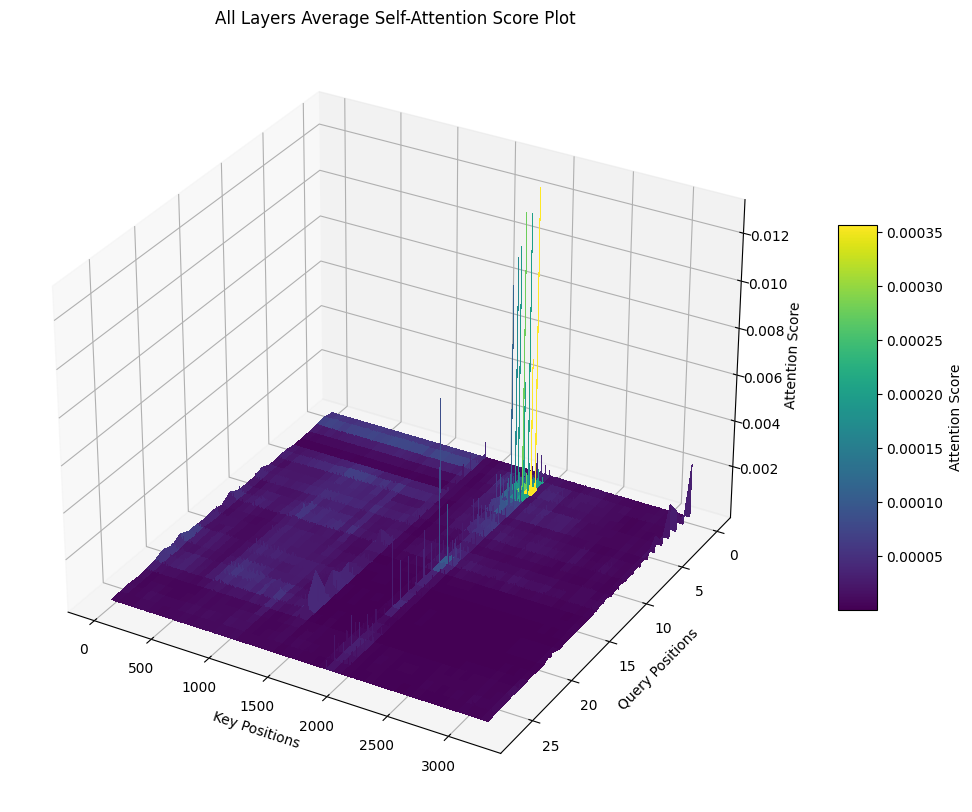

In [15]:
plot_attention_surface(all_layers, title=f"All Layers Average Self-Attention Score Plot")

In [ ]:
fn = extract_vae_vit

vmax = 0
vmin = 1
# vmax = None
# vmin = None

layer_idxes = [0, 5, 10, 15, 20, 25, 27]
timestep = 20

local_vmins = []
local_vmaxs = []

low_percentile = 1.0
high_percentile = 99.0

for layer_idx in layer_idxes:
    tmp_file = f"./{load_dir}/gen_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
    all_entries = torch.load(tmp_file)
    attn_map = all_entries[0]['data']
    
    attn_map = fn(attn_map)
    
    local_vmins.append(torch.quantile(attn_map.float(), low_percentile / 100.0))
    local_vmaxs.append(torch.quantile(attn_map.float(), high_percentile / 100.0))


vmin = torch.tensor(local_vmins).mean().item()
vmax = torch.tensor(local_vmaxs).mean().item()

print(f"Overall vmin: {vmin}, vmax: {vmax}")

load_dir = "attn_probs_dump"

for layer_idx in layer_idxes:
    tmp_file = f"./{load_dir}/gen_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
    all_entries = torch.load(tmp_file)
    print(tmp_file)

    print(f"文件中总共保存了 {len(all_entries)} 个注意力图。")

    for i, entry in enumerate(all_entries):
        attn_map = entry['data']
        print(f"  张量形状: {attn_map.shape}")
        # attn_map = attn_map.mean(dim=0) # [1:-1, 1:-1]

        # attn_map = attn_map[:, 49:1425]
        # attn_map = attn_map[:, 1427:3240]

        # cols_to_remove = [0, 47, 48, 1425, 1426, 3240, 3241, 3253, 3254, 3482, 3483, 4860]
        # rows_to_remove = [0, 1377]
        # num_cols = attn_map.shape[1]
        # num_rows = attn_map.shape[0]
        # cols_to_keep = [i for i in range(num_cols) if i not in cols_to_remove]
        # rows_to_keep = [i for i in range(num_rows) if i not in rows_to_remove]
        # attn_map = attn_map[rows_to_keep, :][:, cols_to_keep]
        attn_map = fn(attn_map)

        # print(attn_map[:, 3481:3485])
        # attn_map = attn_map[:, 3400:]
        # attention_plot(attn_map, x_texts=[f"K{i}" for i in range(attn_map.shape[1])],
        #                y_texts=[f"Q{i}" for i in range(attn_map.shape[0])],
        #                figure_name=f"attn_map_{i+1}.png")
        attention_plot(attn_map, x_texts=None,
                    y_texts=None,
                    figure_name=f"attn_map_{i+1}.png", vmin=vmin, vmax=vmax)
        break


/tmp/ipykernel_1399582/679890132.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_entries = torch.load(tmp_file)


./attn_probs_qkv_dump/gen_qkv_attn_probs_layer_0_ts_5_batch_0.pt
文件中总共保存了 1 个注意力图。
  张量形状: torch.Size([28, 1378, 4869])
(3492, 4868)
  张量形状: torch.Size([1376, 1376])


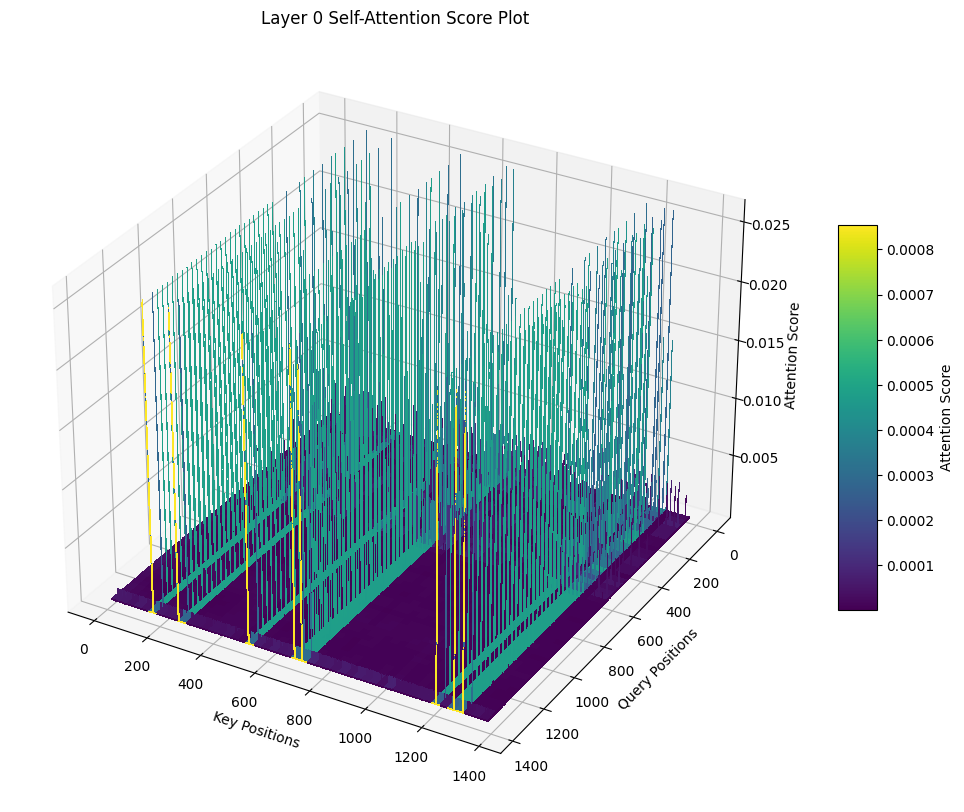

./attn_probs_qkv_dump/gen_qkv_attn_probs_layer_5_ts_5_batch_0.pt
文件中总共保存了 1 个注意力图。
  张量形状: torch.Size([28, 1378, 4869])
(3492, 4868)
  张量形状: torch.Size([1376, 1376])


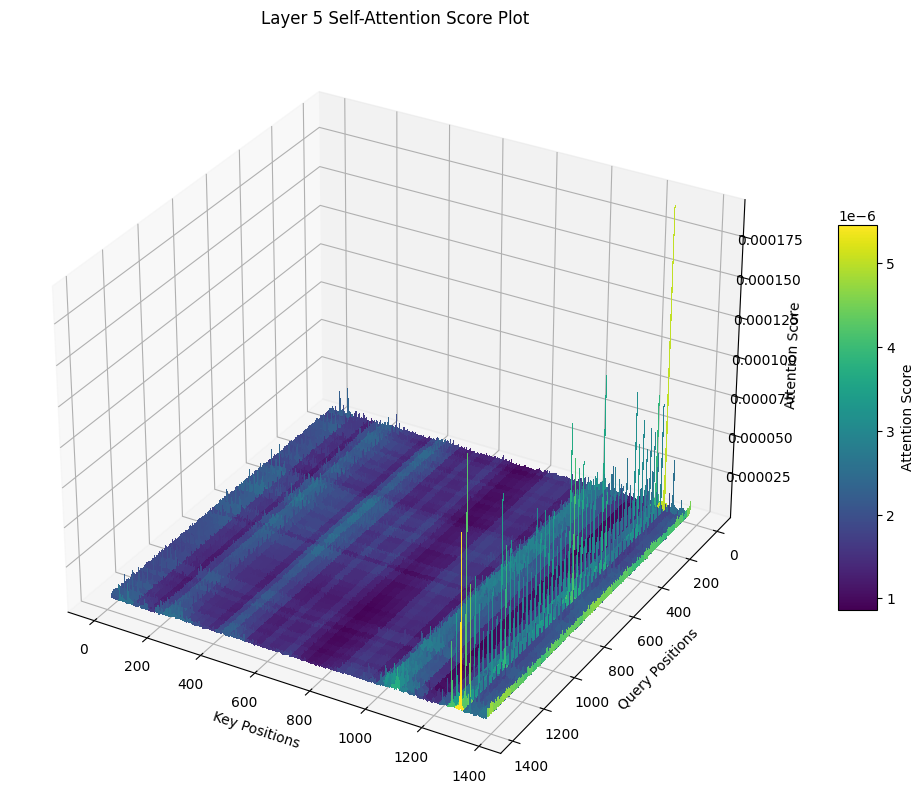

./attn_probs_qkv_dump/gen_qkv_attn_probs_layer_10_ts_5_batch_0.pt
文件中总共保存了 1 个注意力图。
  张量形状: torch.Size([28, 1378, 4869])
(3492, 4868)
  张量形状: torch.Size([1376, 1376])


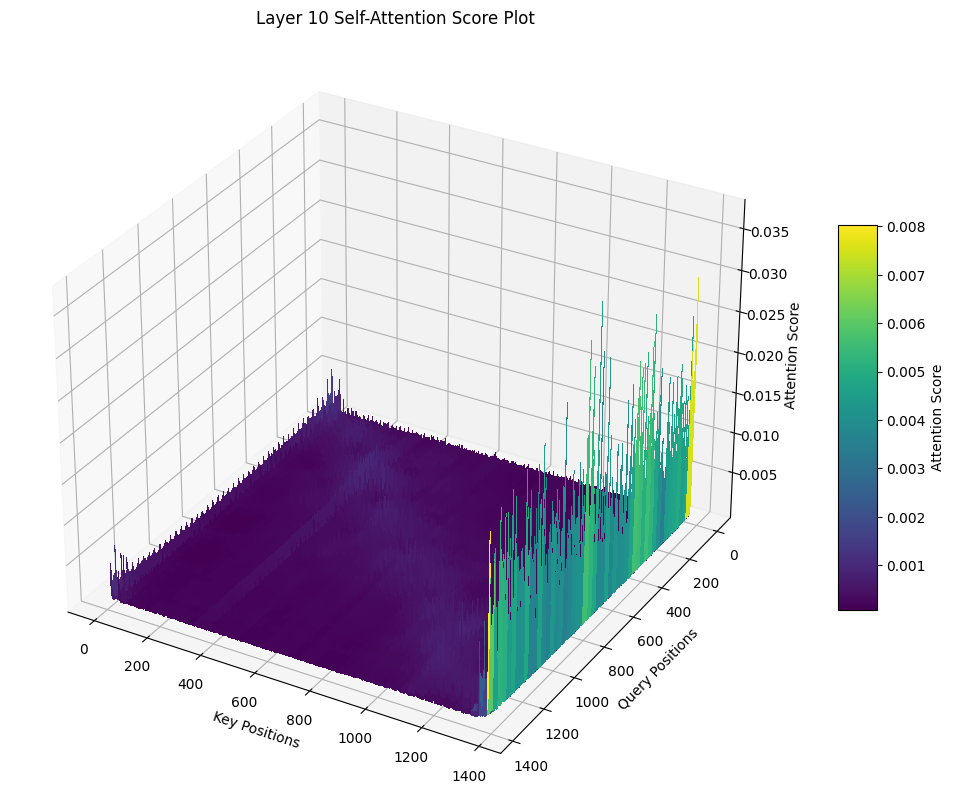

./attn_probs_qkv_dump/gen_qkv_attn_probs_layer_15_ts_5_batch_0.pt
文件中总共保存了 1 个注意力图。
  张量形状: torch.Size([28, 1378, 4869])
(3492, 4868)
  张量形状: torch.Size([1376, 1376])


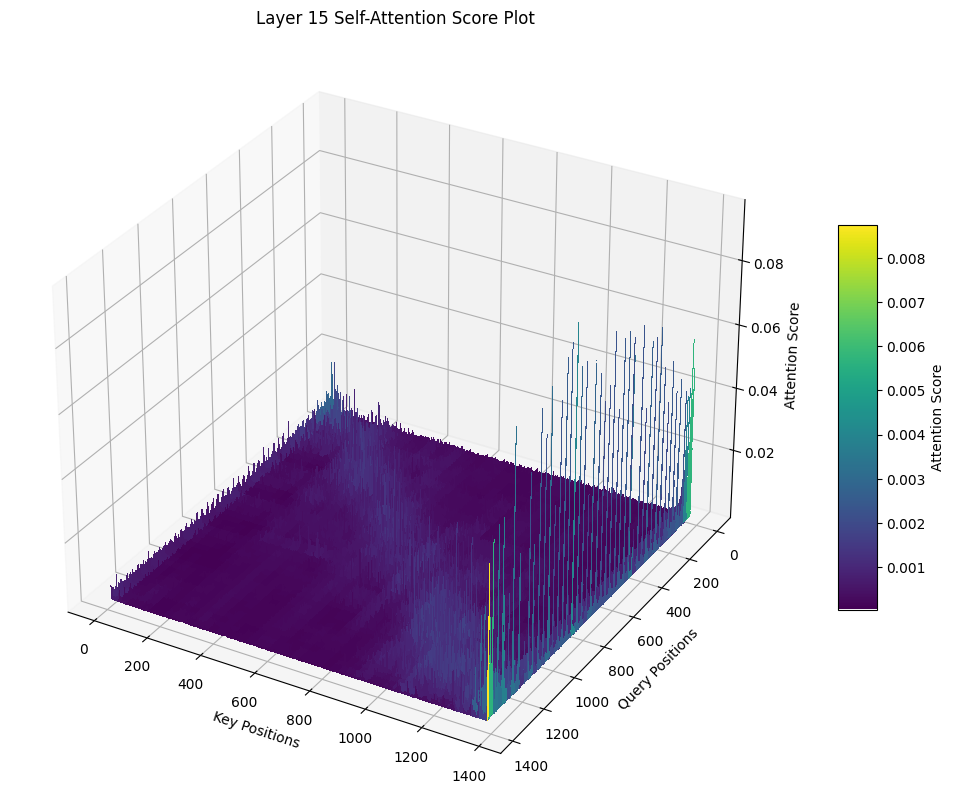

./attn_probs_qkv_dump/gen_qkv_attn_probs_layer_20_ts_5_batch_0.pt
文件中总共保存了 1 个注意力图。
  张量形状: torch.Size([28, 1378, 4869])
(3492, 4868)
  张量形状: torch.Size([1376, 1376])


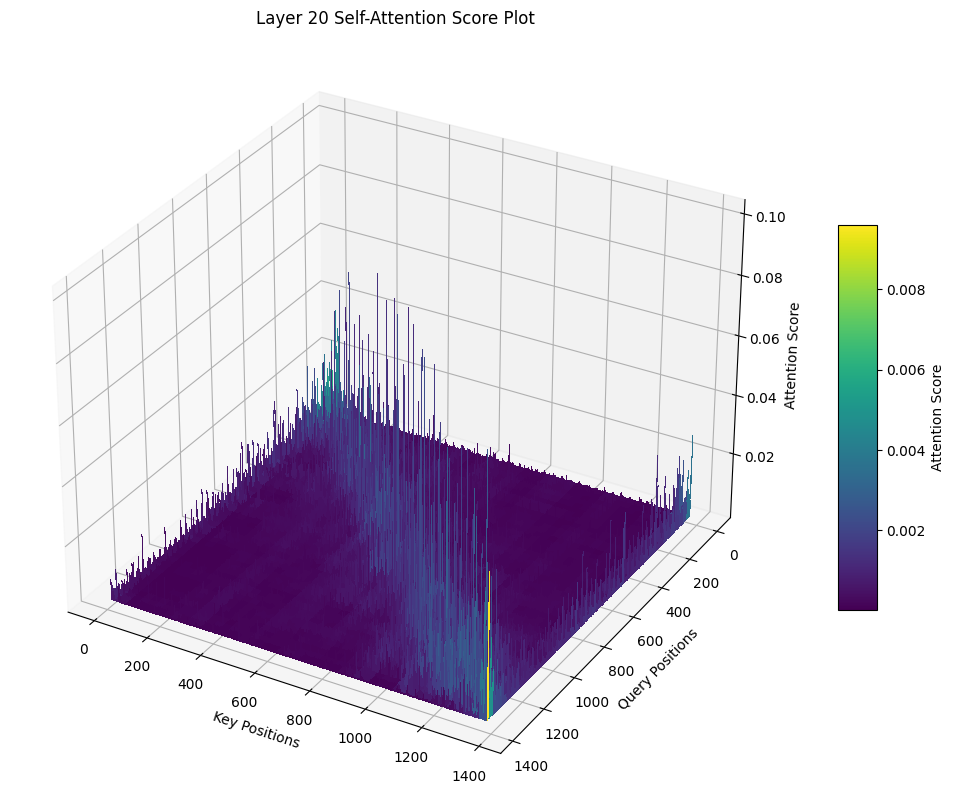

./attn_probs_qkv_dump/gen_qkv_attn_probs_layer_25_ts_5_batch_0.pt
文件中总共保存了 1 个注意力图。
  张量形状: torch.Size([28, 1378, 4869])
(3492, 4868)
  张量形状: torch.Size([1376, 1376])


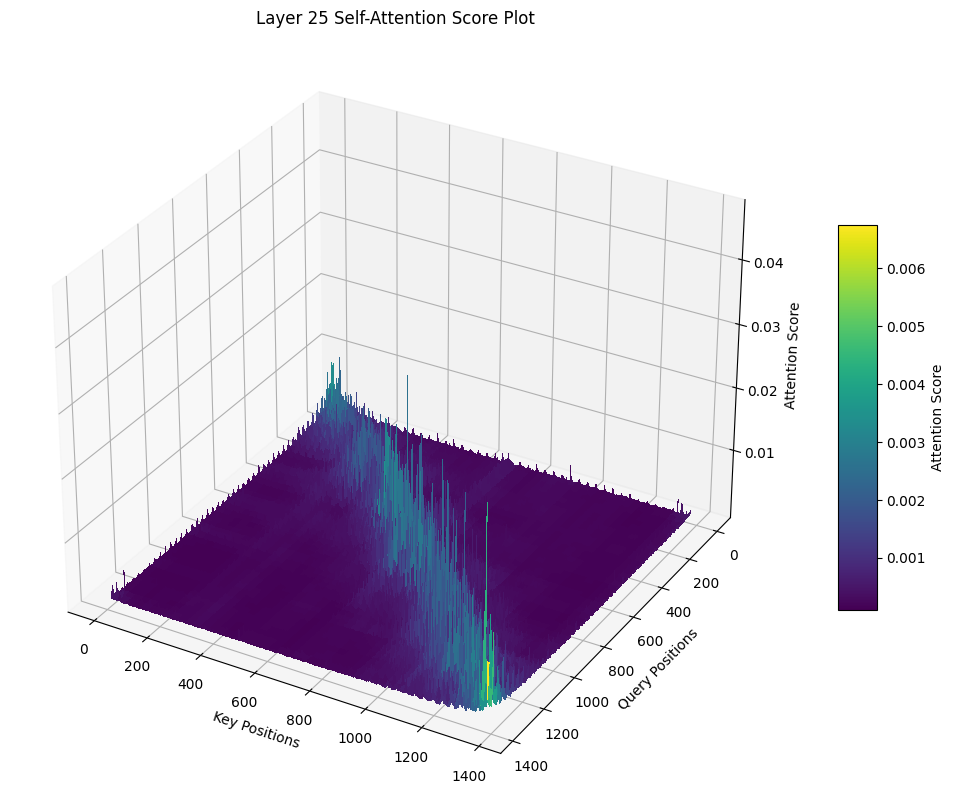

./attn_probs_qkv_dump/gen_qkv_attn_probs_layer_27_ts_5_batch_0.pt
文件中总共保存了 1 个注意力图。
  张量形状: torch.Size([28, 1378, 4869])
(3492, 4868)
  张量形状: torch.Size([1376, 1376])


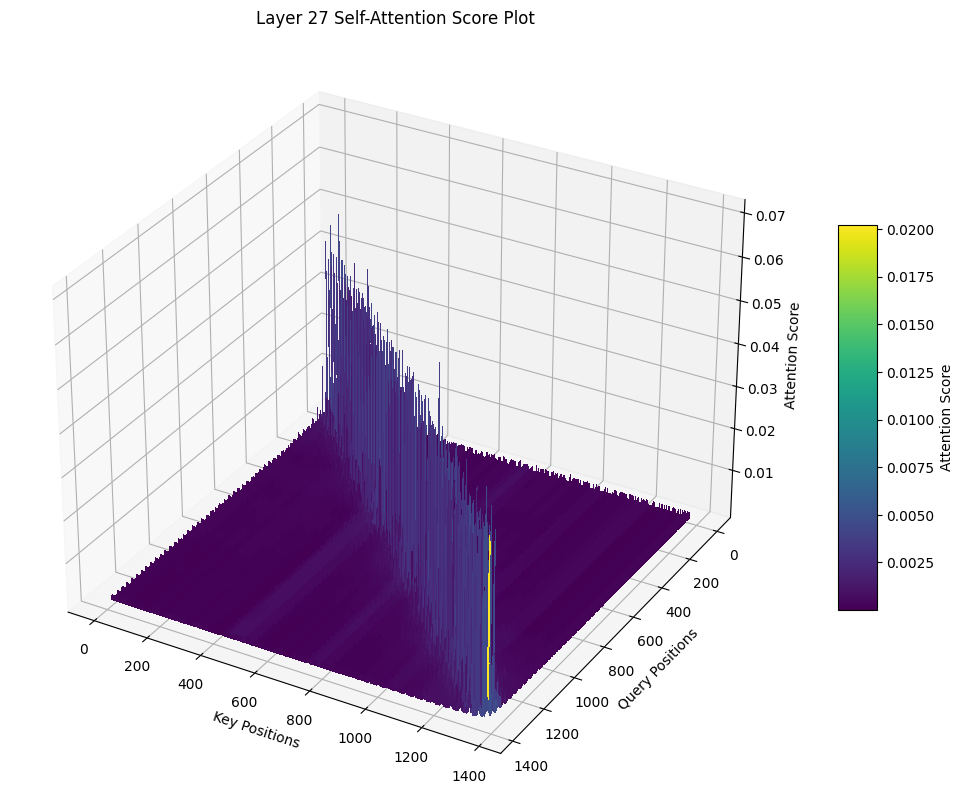

In [8]:
fn = extract_self

# vmax = 0
# vmin = 1
vmax = None
vmin = None

layer_idxes = [0, 5, 10, 15, 20, 25, 27]
timestep = 5

local_vmins = []
local_vmaxs = []

load_dir = "attn_probs_qkv_dump"
elem = 'attn_probs'

# low_percentile = 1.0
# high_percentile = 99.0

# for layer_idx in layer_idxes:
#     tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
#     all_entries = torch.load(tmp_file)
#     attn_map = all_entries[0][elem]
    
#     attn_map = fn(attn_map)
#     local_vmins.append(torch.min(attn_map.flatten()).item())
#     local_vmaxs.append(torch.max(attn_map.flatten()).item())
    # local_vmins.append(torch.quantile(attn_map.float(), low_percentile / 100.0))
    # local_vmaxs.append(torch.quantile(attn_map.float(), high_percentile / 100.0))


# vmin = torch.tensor(local_vmins).mean().item()
# vmax = torch.tensor(local_vmaxs).mean().item()

# print(f"Overall vmin: {local_vmins}\nOverall vmax: {local_vmaxs}")

for layer_idx in layer_idxes:
    tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
    all_entries = torch.load(tmp_file)
    print(tmp_file)

    print(f"文件中总共保存了 {len(all_entries)} 个注意力图。")

    for i, entry in enumerate(all_entries):
        # metadata = entry['metadata']
        attn_map = entry[elem]
        # attn_map = attn_map.mean(dim=0) # [1:-1, 1:-1]

        # attn_map = attn_map[:, 49:1425]
        # attn_map = attn_map[:, 1427:3240]

        # cols_to_remove = [0, 47, 48, 1425, 1426, 3240, 3241, 3253, 3254, 3482, 3483, 4860]
        # rows_to_remove = [0, 1377]
        # num_cols = attn_map.shape[1]
        # num_rows = attn_map.shape[0]
        # cols_to_keep = [i for i in range(num_cols) if i not in cols_to_remove]
        # rows_to_keep = [i for i in range(num_rows) if i not in rows_to_remove]
        # attn_map = attn_map[rows_to_keep, :][:, cols_to_keep]
        print(f"  张量形状: {attn_map.shape}")
        attn_map = fn(attn_map)
        print(f"  张量形状: {attn_map.shape}")
        # print(attn_map[3][1375])
        # print(attn_map[3][1375])
        # break
        plot_attention_surface(attn_map, title=f"Layer {layer_idx} Self-Attention Score Plot")
        # attention_plot(attn_map, x_texts=None,
        #             y_texts=None,
        #             figure_name=f"attn_map_{i+1}.png", vmin=vmin, vmax=vmax)
        # attn_map = abs(attn_map.float())
        # attn_map_np = attn_map.detach().cpu().numpy()
        # print(np.sum(attn_map_np == 0.0))
        # print(np.min(attn_map_np))
        # plot_attn_map_distribution(abs(attn_map.float()), title=f"Layer {layer_idx} Past {elem} (VAE + ViT) Distribution", vmin=vmin, vmax=vmax)
        break
    # break


In [ ]:
# fn = extract_vae_vit
fn = extract_self
load_dir = "attn_probs_qkv_dump"
elem = 'attn_probs'

# vmax = 0
# vmin = 1
vmax = None
vmin = None

layer_idxes = [0, 5, 10, 15, 20, 25, 27]
# layer_idxes = list(range(28))
timestep = 5

local_vmaxs = []

low_percentile = 1.0
high_percentile = 99.0

for layer_idx in layer_idxes:
    tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
    all_entries = torch.load(tmp_file)
    attn_map = all_entries[0][elem]
    
    attn_map = abs(fn(attn_map))
    
    local_vmaxs.append(torch.quantile(attn_map.float(), high_percentile / 100.0))

vmin = 0
vmax = torch.tensor(local_vmaxs).mean().item()

print(f"Overall vmin: {vmin}, vmax: {vmax}")

for layer_idx in layer_idxes:
    tmp_file = f"./{load_dir}/gen_qkv_attn_probs_layer_{layer_idx}_ts_{timestep}_batch_0.pt"
    all_entries = torch.load(tmp_file)
    print(tmp_file)

    print(f"文件中总共保存了 {len(all_entries)} 个注意力图")

    for i, entry in enumerate(all_entries):
        # metadata = entry['metadata']
        attn_map = entry[elem]

        attn_map = fn(attn_map)
        print(f"  张量形状: {attn_map.shape}")
        attn_map_abs = abs(attn_map.float())
        attn_map_np = attn_map_abs.detach().cpu().numpy()
        print(np.sum(attn_map_np == 0.0))
        plot_attn_map_distribution(abs(attn_map.float()), title=f"Layer {layer_idx} {elem} (Self-Attention) Distribution", vmin=vmin, vmax=vmax)
        break
    # break
